# PART A

### TASK 1

In [2]:
import pandas as pd
df = pd.read_csv("hotel_bookings.csv")

print(df.head())
print(df.shape)
print(df.info())
print(df.describe())
print(df.dtypes)
print(df["is_canceled"].value_counts())
print(df["is_canceled"].value_counts(normalize=True) * 100)


y = df["is_canceled"]
X = df.drop("is_canceled", axis=1)

numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("\nNumerical Columns:")
print(numerical_cols)
print("\nCategorical Columns:")
print(categorical_cols)
print("\nNumber of Numerical Columns:", len(numerical_cols))
print("Number of Categorical Columns:", len(categorical_cols))

          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel            0        342               2015               July   
1  Resort Hotel            0        737               2015               July   
2  Resort Hotel            0          7               2015               July   
3  Resort Hotel            0         13               2015               July   
4  Resort Hotel            0         14               2015               July   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   
3                        27                          1   
4                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  ...  deposit_type  \
0                        0                     0       2  ...    No Deposit   
1     

### TASK 2

Missing Values:
                                Missing Count  Missing Percentage
company                                112593           94.306893
agent                                   16340           13.686238
country                                   488            0.408744
children                                    4            0.003350
reserved_room_type                          0            0.000000
assigned_room_type                          0            0.000000
booking_changes                             0            0.000000
deposit_type                                0            0.000000
hotel                                       0            0.000000
previous_cancellations                      0            0.000000
days_in_waiting_list                        0            0.000000
customer_type                               0            0.000000
adr                                         0            0.000000
required_car_parking_spaces                 0            0.0

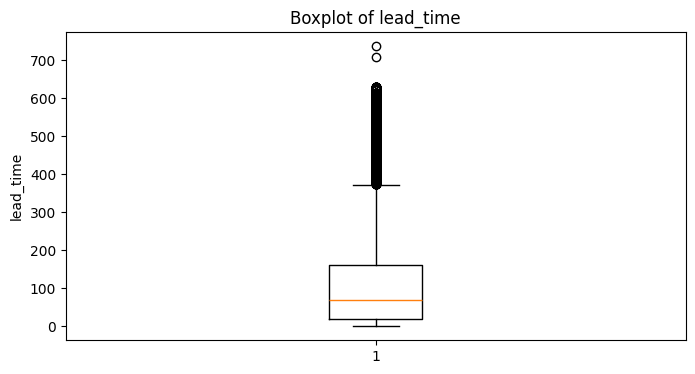

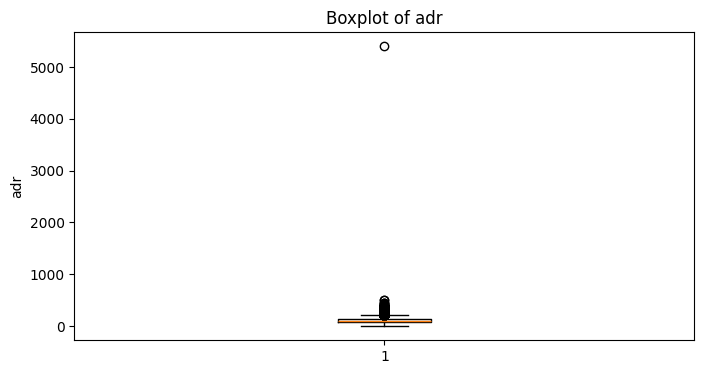

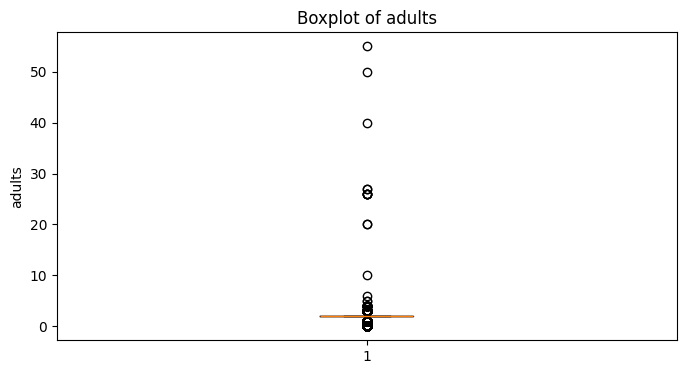

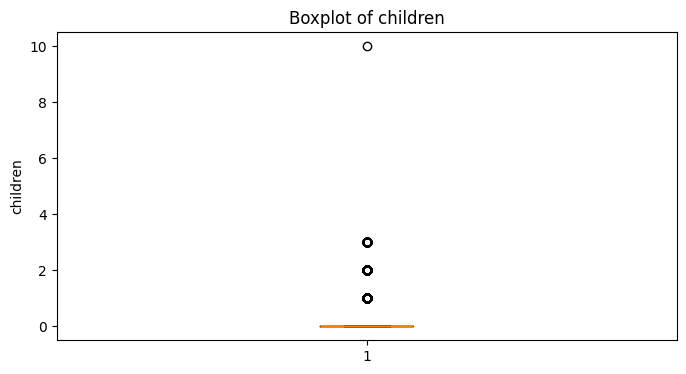

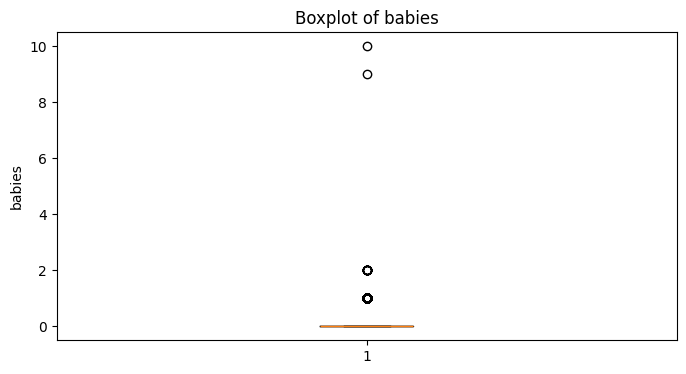

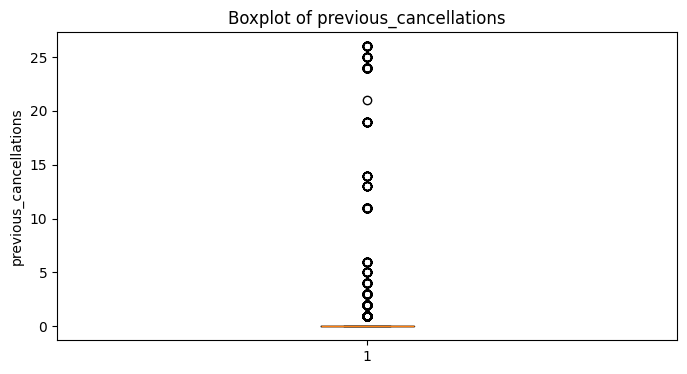

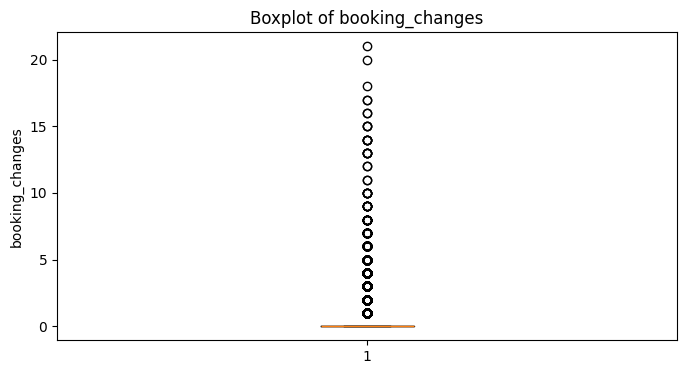

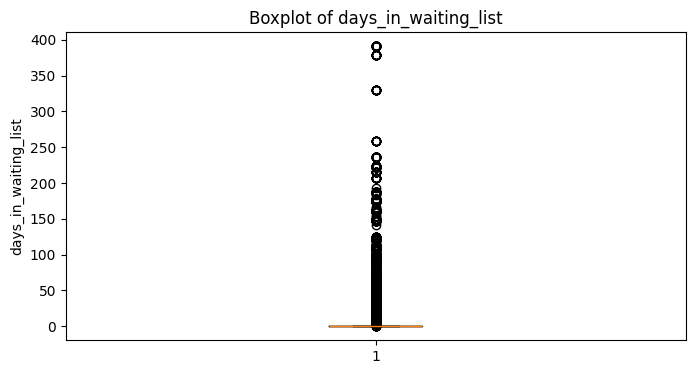


Outlier Information:

Column: lead_time
Q1: 18.0
Q3: 160.0
IQR: 142.0
Lower Bound: -195.0
Upper Bound: 373.0
Number of outliers: 3005

Column: adr
Q1: 69.29
Q3: 126.0
IQR: 56.709999999999994
Lower Bound: -15.774999999999991
Upper Bound: 211.065
Number of outliers: 3793

Column: adults
Q1: 2.0
Q3: 2.0
IQR: 0.0
Lower Bound: 2.0
Upper Bound: 2.0
Number of outliers: 29710

Column: children
Q1: 0.0
Q3: 0.0
IQR: 0.0
Lower Bound: 0.0
Upper Bound: 0.0
Number of outliers: 8590

Column: babies
Q1: 0.0
Q3: 0.0
IQR: 0.0
Lower Bound: 0.0
Upper Bound: 0.0
Number of outliers: 917

Column: previous_cancellations
Q1: 0.0
Q3: 0.0
IQR: 0.0
Lower Bound: 0.0
Upper Bound: 0.0
Number of outliers: 6484

Column: booking_changes
Q1: 0.0
Q3: 0.0
IQR: 0.0
Lower Bound: 0.0
Upper Bound: 0.0
Number of outliers: 18076

Column: days_in_waiting_list
Q1: 0.0
Q3: 0.0
IQR: 0.0
Lower Bound: 0.0
Upper Bound: 0.0
Number of outliers: 3698

Rows before outlier/invalid-value removal: 119390
Rows after outlier/invalid-value rem

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

missing_count = df.isnull().sum()
missing_percentage = (missing_count / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percentage
})

print("Missing Values:")
print(missing_table.sort_values(by="Missing Percentage", ascending=False))
high_missing = missing_table[missing_table["Missing Percentage"] > 50]

print("\nColumns with more than 50% missing values:")
print(high_missing)

if "company" in df.columns:
    df = df.drop("company", axis=1)
leakage_columns = [
    "reservation_status",
    "reservation_status_date"
]

df = df.drop(columns=leakage_columns)


print("\nLeakage columns removed:")
print(leakage_columns)
print("\nMissing Values After Dropping Columns:")
print(df.isnull().sum())

outlier_columns = [
    "lead_time",
    "adr",
    "adults",
    "children",
    "babies",
    "previous_cancellations",
    "booking_changes",
    "days_in_waiting_list"
]

for column in outlier_columns:
    plt.figure(figsize=(8, 4))
    plt.boxplot(df[column].dropna())
    plt.title("Boxplot of " + column)
    plt.ylabel(column)
    plt.show()

for column in outlier_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    print("\nColumn:", column)
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)
    print("Number of outliers:", len(outliers))


rows_before = len(df)

df = df[df["adr"] >= 0]
df = df[(df["adults"] >= 0) &(df["children"] >= 0) &(df["babies"] >= 0)]

df = df[df["adr"] < 5000]
rows_after = len(df)
rows_removed = rows_before - rows_after

print("\nRows before outlier/invalid-value removal:", rows_before)
print("Rows after outlier/invalid-value removal:", rows_after)
print("Total rows removed:", rows_removed)
print("\nFinal Dataset Shape:")
print(df.shape)
df.to_csv("hotel_bookings_cleaned.csv", index=False)

### TASK 3

In [5]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder

X = df.drop("is_canceled", axis=1)
y = df["is_canceled"]

numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical Columns:")
print(numerical_cols)

print("\nCategorical Columns:")
print(categorical_cols)

X_train, X_test, y_train, y_test = train_test_split(
    X,y, test_size=0.2,stratify=y,random_state=42)


print("\nTraining Data Shape:")
print(X_train.shape)

print("\nTesting Data Shape:")
print(X_test.shape)

numerical_pipeline_A = Pipeline([("imputer", KNNImputer(n_neighbors=5)),("scaler", StandardScaler())])

numerical_pipeline_B = Pipeline([("imputer", KNNImputer(n_neighbors=5)),("scaler", MinMaxScaler())])

categorical_pipeline = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),("encoder", OneHotEncoder(handle_unknown="ignore"))])


preprocessor_A = ColumnTransformer([("numerical", numerical_pipeline_A, numerical_cols),("categorical", categorical_pipeline, categorical_cols)])

preprocessor_B = ColumnTransformer([("numerical", numerical_pipeline_B, numerical_cols),("categorical", categorical_pipeline, categorical_cols)])

pipeline_A = Pipeline([("preprocessor", preprocessor_A)])

pipeline_B = Pipeline([("preprocessor", preprocessor_B)])


pipeline_A.fit(X_train)

X_train_A = pipeline_A.transform(X_train)
X_test_A = pipeline_A.transform(X_test)

pipeline_B.fit(X_train)

X_train_B = pipeline_B.transform(X_train)
X_test_B = pipeline_B.transform(X_test)

print("\nPipeline A:")
print("X_train_A shape:", X_train_A.shape)
print("X_test_A shape:", X_test_A.shape)

print("\nPipeline B:")
print("X_train_B shape:", X_train_B.shape)
print("X_test_B shape:", X_test_B.shape)

Numerical Columns:
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']

Categorical Columns:
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']

Training Data Shape:
(95507, 28)

Testing Data Shape:
(23877, 28)

Pipeline A:
X_train_A shape: (95507, 249)
X_test_A shape: (23877, 249)

Pipeline B:
X_train_B shape: (95507, 249)
X_test_B shape: (23877, 249)


# PART B

### TASK 4

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

logistic_A = Pipeline([
    ("preprocessor", preprocessor_A),
    ("classifier", LogisticRegression(max_iter=1000))
])

logistic_B = Pipeline([
    ("preprocessor", preprocessor_B),
    ("classifier", LogisticRegression(max_iter=1000))
])

decision_tree_A = Pipeline([
    ("preprocessor", preprocessor_A),
    ("classifier", DecisionTreeClassifier(random_state=42))
])
decision_tree_B = Pipeline([
    ("preprocessor", preprocessor_B),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

logistic_A.fit(X_train, y_train)

logistic_B.fit(X_train, y_train)

decision_tree_A.fit(X_train, y_train)

decision_tree_B.fit(X_train, y_train)


print("All four model-pipeline combinations have been trained successfully.")

All four model-pipeline combinations have been trained successfully.


### TASK 5

Final Model Comparison:
                     Model-Pipeline  Training Accuracy  Testing Accuracy  \
0  Logistic Regression - Pipeline A             0.8188            0.8167   
1  Logistic Regression - Pipeline B             0.8146            0.8125   
2        Decision Tree - Pipeline A             0.9962            0.8574   
3        Decision Tree - Pipeline B             0.9962            0.8575   

   Precision  Recall  F1-Score  Train-Test Difference  
0     0.8049  0.6668    0.7294                 0.0020  
1     0.8028  0.6545    0.7211                 0.0021  
2     0.8051  0.8116    0.8083                 0.1388  
3     0.8055  0.8112    0.8083                 0.1387  

Results Sorted by F1-Score:
                     Model-Pipeline  Training Accuracy  Testing Accuracy  \
3        Decision Tree - Pipeline B             0.9962            0.8575   
2        Decision Tree - Pipeline A             0.9962            0.8574   
0  Logistic Regression - Pipeline A             0.8188    

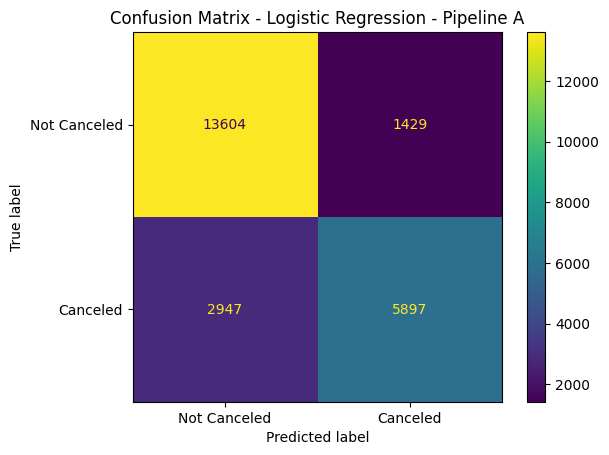

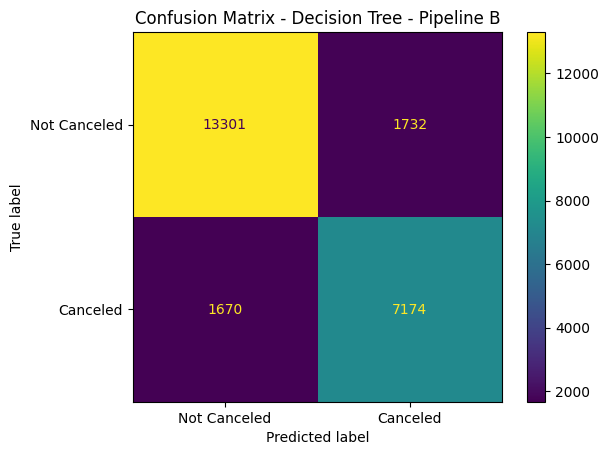


Overfitting Analysis:

Logistic Regression - Pipeline A
Training Accuracy: 0.8188
Testing Accuracy: 0.8167
Train-Test Difference: 0.002
No major sign of overfitting.

Logistic Regression - Pipeline B
Training Accuracy: 0.8146
Testing Accuracy: 0.8125
Train-Test Difference: 0.0021
No major sign of overfitting.

Decision Tree - Pipeline A
Training Accuracy: 0.9962
Testing Accuracy: 0.8574
Train-Test Difference: 0.1388
Possible strong overfitting.

Decision Tree - Pipeline B
Training Accuracy: 0.9962
Testing Accuracy: 0.8575
Train-Test Difference: 0.1387
Possible strong overfitting.

Best Logistic Regression:
Logistic Regression - Pipeline A

Best Decision Tree:
Decision Tree - Pipeline B


In [7]:
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,ConfusionMatrixDisplay)
import pandas as pd
import matplotlib.pyplot as plt

models = {
    "Logistic Regression - Pipeline A": logistic_A,
    "Logistic Regression - Pipeline B": logistic_B,
    "Decision Tree - Pipeline A": decision_tree_A,
    "Decision Tree - Pipeline B": decision_tree_B
}
results = []

for name, model in models.items():
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)

    precision = precision_score(y_test,y_test_pred,zero_division=0)

    recall = recall_score(y_test,y_test_pred,zero_division=0)

    f1 = f1_score(y_test,y_test_pred,zero_division=0)
    accuracy_difference = train_accuracy - test_accuracy

    results.append({
        "Model-Pipeline": name,
        "Training Accuracy": train_accuracy,
        "Testing Accuracy": test_accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "Train-Test Difference": accuracy_difference
    })

results_df = pd.DataFrame(results)

print("Final Model Comparison:")
print(results_df.round(4))

results_sorted = results_df.sort_values(
    by="F1-Score",
    ascending=False
)

print("\nResults Sorted by F1-Score:")
print(results_sorted.round(4))

logistic_results = results_df[
    results_df["Model-Pipeline"].str.contains("Logistic Regression")
]

best_logistic = logistic_results.loc[
    logistic_results["F1-Score"].idxmax()
]

print("\nBest Logistic Regression Result:")
print(best_logistic)

tree_results = results_df[
    results_df["Model-Pipeline"].str.contains("Decision Tree")
]

best_tree = tree_results.loc[
    tree_results["F1-Score"].idxmax()
]

print("\nBest Decision Tree Result:")
print(best_tree)

best_logistic_name = best_logistic["Model-Pipeline"]
best_logistic_model = models[best_logistic_name]

best_tree_name = best_tree["Model-Pipeline"]
best_tree_model = models[best_tree_name]

y_pred_logistic = best_logistic_model.predict(X_test)

cm_logistic = confusion_matrix(y_test, y_pred_logistic)

ConfusionMatrixDisplay(confusion_matrix=cm_logistic,display_labels=["Not Canceled", "Canceled"]).plot()
plt.title("Confusion Matrix - " + best_logistic_name)
plt.show()

y_pred_tree = best_tree_model.predict(X_test)

cm_tree = confusion_matrix(
    y_test,
    y_pred_tree
)
ConfusionMatrixDisplay(
    confusion_matrix=cm_tree,
    display_labels=["Not Canceled", "Canceled"]
).plot()

plt.title("Confusion Matrix - " + best_tree_name)
plt.show()
print("\nOverfitting Analysis:")

for index, row in results_df.iterrows():
    difference = row["Train-Test Difference"]
    print("\n" + row["Model-Pipeline"])
    print("Training Accuracy:",round(row["Training Accuracy"], 4) )

    print("Testing Accuracy:", round(row["Testing Accuracy"], 4))

    print( "Train-Test Difference:",  round(difference, 4))

    if difference > 0.10:
        print("Possible strong overfitting.")
    elif difference > 0.05:
        print("Some possible overfitting.")
    else:
        print("No major sign of overfitting.")

print("\nBest Logistic Regression:")
print(best_logistic_name)

print("\nBest Decision Tree:")
print(best_tree_name)

### TASK 6

### 1. Which preprocessing-model combination gives the best overall result?

-Training Accuracy: 0.996336

-Testing Accuracy: 0.860206

-Precision: 0.808446

-Recall: 0.815941

-F1-Score: 0.812176


Among all four experiments, Decision Tree with Pipeline A achieved the highest testing accuracy and F1-score. Therefore, it can be considered the best-performing preprocessing-model combination for this dataset.

### 2. Does StandardScaler or MinMaxScaler affect Logistic Regression?

| Metric | StandardScaler | MinMaxScaler |
|---|---:|---:|
| Testing Accuracy | **0.818829** | 0.813301 |
| Precision | **0.811269** | 0.808292 |
| Recall | **0.665800** | 0.650198 |
| F1-Score | **0.731371** | 0.720677 |

Based on the results, **StandardScaler performs slightly better than MinMaxScaler** for Logistic Regression. It gives higher values for testing accuracy, precision, recall, and F1-score. However, the difference between the two scaling methods is relatively small.

### 3. Does scaling make a major difference for Decision Tree?

No, scaling does not make a significant difference for the Decision Tree. The performance remains almost the same with both StandardScaler and MinMaxScaler.

This is expected because Decision Trees split the data based on feature thresholds rather than the actual scale of the features. Therefore, unlike Logistic Regression, changing the scaling method has very little impact on Decision Tree performance.

## Observations
Decision Tree models achieved better testing performance than Logistic Regression models, with the best Decision Tree reaching around 86.0% accuracy, compared with approximately 81.9% for the best Logistic Regression model.

The Decision Tree with Pipeline A (StandardScaler) gave the strongest overall performance, with a testing accuracy of 86.02% and an F1-score of 0.8122.

For Logistic Regression, StandardScaler showed a slight advantage over MinMaxScaler, giving better results in terms of accuracy, precision, recall, and F1-score.

Changing the scaling method had almost no impact on the Decision Tree, since both StandardScaler and MinMaxScaler produced very similar results.

The Decision Tree appears to have some overfitting, as its training accuracy (99.63%) is considerably higher than its testing accuracy (86.02%). In comparison, Logistic Regression showed a smaller difference between training and testing performance.